In [367]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [368]:
from sklearn.datasets import fetch_california_housing

In [369]:
data=fetch_california_housing()

In [370]:
data=dict(data)
cols=data["feature_names"]
df=pd.DataFrame(data["data"])
df.rename(columns={0:"MedInc",1:"HouseAge",2:"AveRooms",3:"AveBedrms",4:"Population",5:"AveOccup",6:"Latitude",7:"Longitude"},inplace=True)


In [371]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [372]:
target=pd.DataFrame(data["target"])
target.rename(columns={0:"MedHouseVal"},inplace=True)

In [373]:
df=pd.concat((df,target),axis=1)

In [374]:
cols.append("MedHouseVal")

In [375]:
test=df.iloc[18000:]
test.to_csv("test.csv",index=None)
df=df.drop(df.index[18000:])

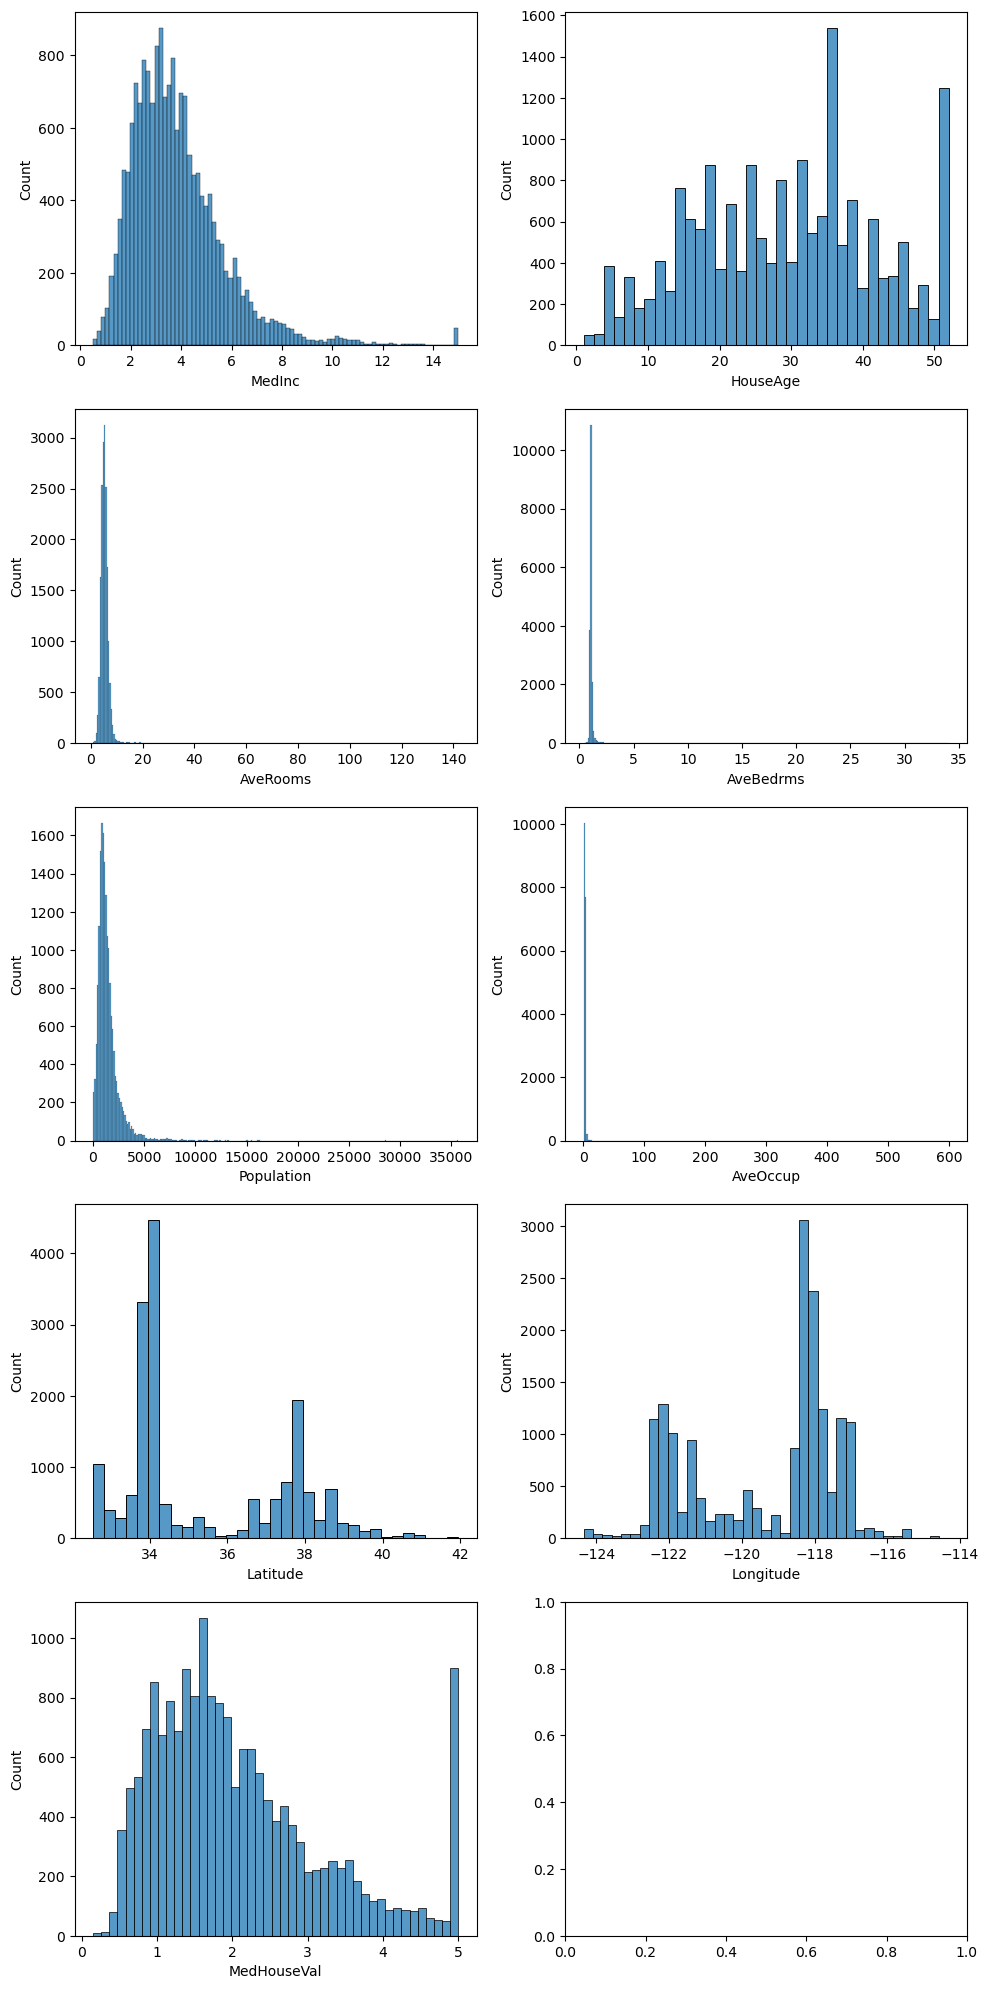

In [376]:

fig,ax=plt.subplots(5,2,figsize=(10,20))
for i,col in enumerate(cols):
    sns.histplot(data=df,x=col,ax=ax[i//2,i%2])

plt.tight_layout()

In [377]:
out=["AveRooms","AveBedrms","Population","AveOccup"]

df["AveBedrms"]=np.log(df["AveBedrms"])
df["AveRooms"]=np.log(df["AveRooms"])
df["Population"]=np.log(df["Population"])
df["AveOccup"]=np.log(df["AveOccup"])


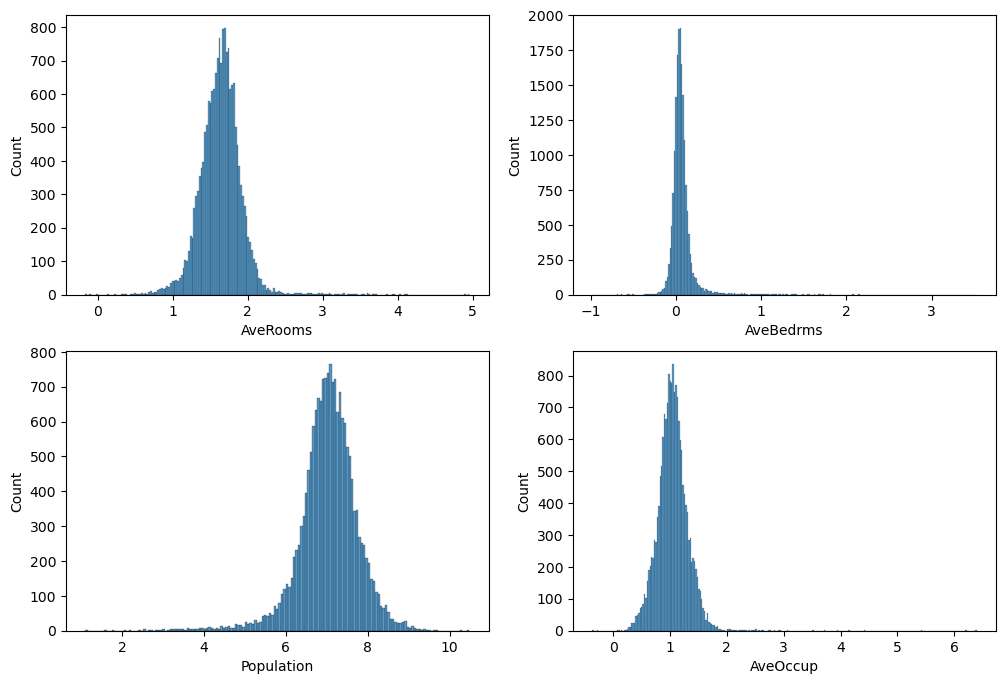

In [378]:
fig,ax=plt.subplots(2,2,figsize=(12,8))

for i,col in enumerate(out):
    sns.histplot(data=df,x=col,ax=ax[i//2,i%2])

<Axes: >

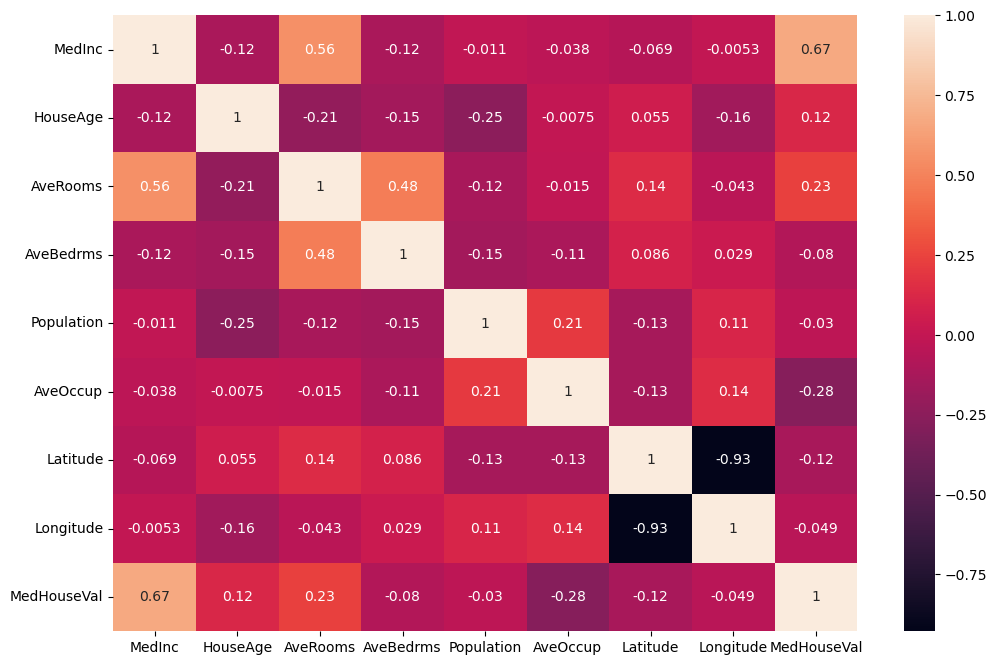

In [379]:
corr=df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True)

In [380]:
test=pd.read_csv("test.csv")
xtest=test.drop("MedHouseVal",axis=1)

xtest["AveBedrms"]=np.log(xtest["AveBedrms"])
xtest["AveRooms"]=np.log(xtest["AveRooms"])
xtest["Population"]=np.log(xtest["Population"])
xtest["AveOccup"]=np.log(xtest["AveOccup"])


ytest=test["MedHouseVal"]

In [381]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

X=df.drop("MedHouseVal",axis=1)
y=df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=42)

pipeline=Pipeline([
    ("scaler",StandardScaler()),
    ("model",LinearRegression())
])

validation=cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    n_jobs=-1
)

pipeline.fit(X_train,y_train)

y_pred=pipeline.predict(xtest)

print(r2_score(ytest,y_pred))
print(mean_squared_error(ytest,y_pred))
print(mean_absolute_error(ytest,y_pred))


0.7355822639853071
0.38659121738247176
0.4451671545264518


In [382]:
print(validation)
print(validation.mean())

[0.65827972 0.63617255 0.67184589 0.65326795 0.63375274]
0.6506637700605985


In [383]:
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

pipeline=Pipeline([
    ("scaler",StandardScaler()),
    ("model",XGBRegressor())
])

pipeline.fit(X_train,y_train)

y_pred=pipeline.predict(xtest)

print(r2_score(ytest,y_pred))
print(mean_absolute_error(ytest,y_pred))
print(mean_squared_error(ytest,y_pred))



0.7963114713607066
0.37736535846567515
0.2978022482165619


In [384]:
from sklearn.ensemble import RandomForestRegressor

pipeline=Pipeline([
    ("scaler",StandardScaler()),
    ("model",RandomForestRegressor())
])

pipeline.fit(X_train,y_train)

y_pred=pipeline.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import StackingRegressor
base_model=[
    ("reg",LinearRegression()),
    ("xgb",XGBRegressor()),
    ("rf",RandomForestRegressor()) 
]

stack=StackingRegressor(
    estimators=base_model,
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

stack.fit(X_train,y_train)

y_pred=stack.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.8287898456332922
0.2810905901995367
0.19074519450749716


In [ ]:
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ============================================
# Load Dataset
# ============================================


# ============================================
# Train Test Split
# ============================================


# ============================================
# Random Forest Tuning
# ============================================

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best RF:", rf_grid.best_params_)

# ============================================
# XGBoost Tuning
# ============================================

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1]
}

xgb_grid = GridSearchCV(
    XGBRegressor(
        random_state=42
    ),
    xgb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

print("Best XGB:", xgb_grid.best_params_)

# ============================================
# LightGBM Tuning
# ============================================

lgbm_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "num_leaves": [31, 50]
}

lgbm_grid = GridSearchCV(
    LGBMRegressor(random_state=42),
    lgbm_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lgbm_grid.fit(X_train, y_train)

best_lgbm = lgbm_grid.best_estimator_

print("Best LGBM:", lgbm_grid.best_params_)

# ============================================
# Stacking
# ============================================

base_models = [
    ("rf", best_rf),
    ("xgb", best_xgb),
    ("lgbm", best_lgbm)
]

stack = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

# ============================================
# Train Stacking Model
# ============================================

stack.fit(X_train, y_train)

# ============================================
# Prediction
# ============================================

y_pred = stack.predict(X_test)

# ============================================
# Evaluation
# ============================================

print("\nR2 Score")
print(r2_score(y_test, y_pred))

print("\nMAE")
print(mean_absolute_error(y_test, y_pred))

print("\nMSE")
print(mean_squared_error(y_test, y_pred))

print("\nRMSE")
print(mean_squared_error(y_test, y_pred) ** 0.5)

KeyboardInterrupt: 

In [386]:
import pickle
pickle.dump(stack,open("stack.pkl","wb"))

In [387]:
model=pickle.load(open("stack.pkl","rb"))

In [389]:
y_pred=model.predict(xtest)
print(r2_score(ytest,y_pred))

0.6429540104054501
